In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
import os

#Load data and model
test_df = pd.read_csv("test_data.csv")

model_path = os.path.expanduser("BAAI/bge-small-en-v1.5")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path)

#Example of using model to get sentence embeddings

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [3]:
sample_text = test_df['text'].iloc[0]

with torch.no_grad():
    encoded_input = tokenizer(sample_text, return_tensors="pt").to(device)
    model_output = model(**encoded_input)

# [CLS] token at index 0 stores embedding of the whole sentence
embedding = model_output[0][:, 0]
embedding.shape

torch.Size([1, 384])

[43, 41, 53, 35, 70, 31, 49, 42, 31, 40, 37, 52, 51, 52, 43, 46, 45, 43, 48, 39, 56, 43, 44, 47, 44, 49, 44, 31, 46, 39, 32, 36, 48, 33, 39, 49, 41, 47, 40, 48, 31, 55, 50, 37, 56, 31, 48, 27, 40, 42, 43, 43, 46, 40, 40, 42, 42, 46, 49, 42, 42, 42, 42, 43, 52, 43, 40, 44, 44, 33, 41, 51, 42, 40, 43, 40, 47, 45, 52, 47, 46, 40, 22, 47, 43, 60, 40, 46, 49, 51, 42, 45, 53, 34, 46, 53, 41, 39, 43, 42, 39, 51, 43, 46, 48, 34, 32, 43, 55, 40, 35, 41, 42, 42, 42, 40, 42, 45, 40, 43, 56, 26, 60, 41, 42, 49, 36, 49, 43, 43, 53, 41, 37, 39, 35, 44, 41, 47, 44, 41, 47, 45, 53, 47, 39, 43, 49, 37, 40, 32, 41, 41, 30, 46, 51, 40, 49, 42, 42, 34, 42, 47, 48, 39, 44, 43, 43, 42, 25, 52, 50, 43, 39, 47, 46, 39, 40, 43, 52, 42, 45, 58, 48, 40, 29, 41, 31, 39, 25, 47, 46, 45, 41, 57, 45, 30, 44, 37, 66, 49, 40, 52, 42, 46, 42, 38, 51, 48, 50, 33, 47, 41, 45, 39, 47, 52, 28, 38, 46, 47, 40, 45, 41, 39, 38, 40, 21, 48, 49, 40, 51, 48, 37, 52, 39, 54, 56, 30, 43, 36, 43, 54, 53, 38, 50, 43, 51, 39, 63, 36,

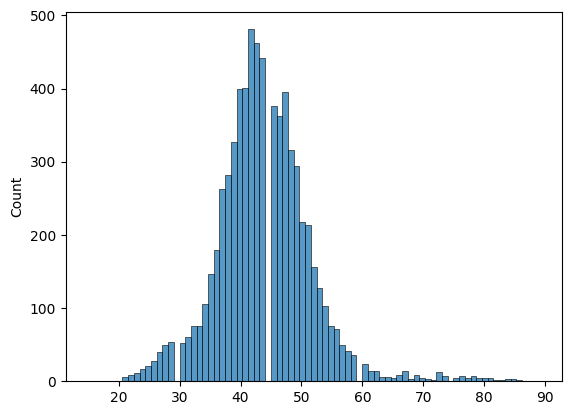

In [7]:
import seaborn as sns

texts = test_df['text'].tolist()
with torch.no_grad():
    encoded_input = tokenizer(texts).to(device)
    lens = [len(encoded_input['input_ids'][i]) for i in range(0, len(encoded_input['input_ids']))]
    print(lens)
    sns.histplot(lens)
    # model_output = model(**encoded_input)

# embedding = model_output[0][:, 0]
# embedding.shape, model_output.shape

In [9]:
MAX_LEN = 64

with torch.no_grad():
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt', max_length=MAX_LEN).to(device)
    model_output = model(**encoded_input)

embedding = model_output[0][:, 0]
embedding.shape

torch.Size([7000, 384])

array([0.04686209, 0.04453205], dtype=float32)

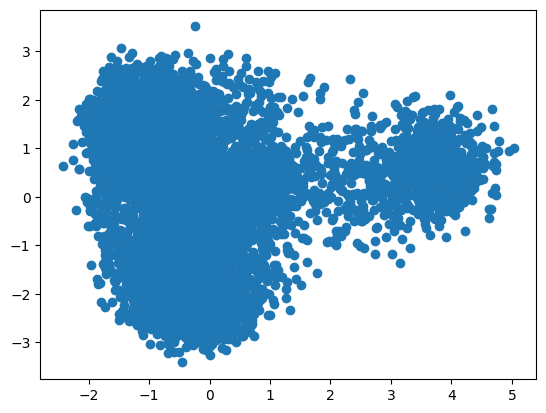

In [19]:
from sklearn.decomposition import PCA
from umap import UMAP
import matplotlib.pyplot as plt
# embedding = embedding.detach().cpu().numpy()

pca = PCA(2)
emb_pca = pca.fit_transform(embedding)
plt.scatter(emb_pca[:, 0], emb_pca[:, 1])
pca.explained_variance_ratio_

0.68742067


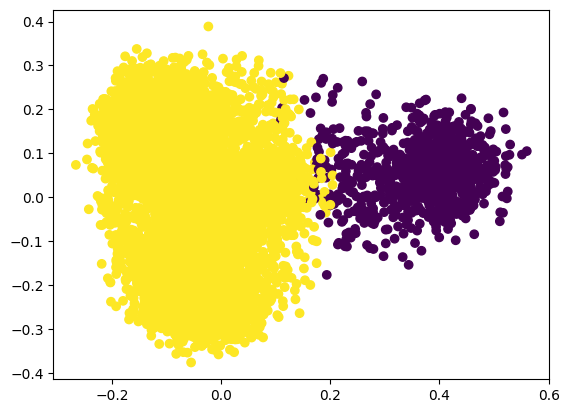

In [46]:
from sklearn.cluster import KMeans, SpectralClustering
kmeans = KMeans(2)
pca = PCA(100)
emb_reduced = pca.fit_transform(embedding)
labels = kmeans.fit_predict(emb_reduced)

plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=labels)
print(pca.explained_variance_ratio_.sum())

In [47]:
labels

array([1, 1, 0, ..., 1, 1, 1], shape=(7000,), dtype=int32)

In [50]:
news_emb = embedding[[i for i in range(len(embedding)) if labels[i]==1]]
news_emb.shape

(6178, 384)

0.079724394


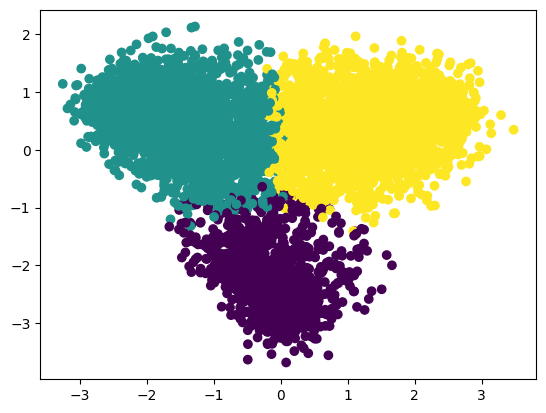

In [55]:
kmeans = KMeans(3)
pca = PCA(100)
emb_reduced = pca.fit_transform(news_emb)
pca = PCA(2)
emb_plot = pca.fit_transform(news_emb)
labels = kmeans.fit_predict(emb_reduced)

plt.scatter(emb_plot[:, 0], emb_plot[:, 1], c=labels)
print(pca.explained_variance_ratio_.sum())